# Capitolo 2 — Controllo numerico del gradiente, gradiente che svanisce, approssimazione universale (§ 2.10–2.12)
Tre esperimenti in NumPy che completano il capitolo.

In [1]:
import sys; sys.path.insert(0, "..")
from utils import fissa_seme
import dati
import numpy as np
import matplotlib.pyplot as plt

def sigmoide(z):
    return 1 / (1 + np.exp(-z))
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

## 2.10 Verificare le derivate: il controllo numerico

In [2]:
def perdita(W1, b1, W2, b2):
    h = sigmoide(X @ W1 + b1)
    y_hat = sigmoide(h @ W2 + b2)
    return np.mean((y_hat - y_xor) ** 2)

fissa_seme(0)
W1 = np.random.randn(2, 3); b1 = np.zeros(3); W2 = np.random.randn(3); b2 = 0.0

# gradiente analitico (backpropagation), solo per W1
h = sigmoide(X @ W1 + b1); y_hat = sigmoide(h @ W2 + b2)
delta2 = 2 * (y_hat - y_xor) / 4 * y_hat * (1 - y_hat)
delta1 = np.outer(delta2, W2) * h * (1 - h)
grad_W1 = X.T @ delta1

# gradiente numerico
eps = 1e-5
grad_num = np.zeros_like(W1)
for i in range(2):
    for j in range(3):
        W_piu = W1.copy();  W_piu[i, j] += eps
        W_meno = W1.copy(); W_meno[i, j] -= eps
        grad_num[i, j] = (perdita(W_piu, b1, W2, b2) - perdita(W_meno, b1, W2, b2)) / (2 * eps)

print(np.round(grad_W1, 6))
print(np.round(grad_num, 6))
print("Differenza massima:", np.abs(grad_W1 - grad_num).max())

[[-0.00337   0.000459 -0.001114]
 [-0.001802 -0.000307 -0.001155]]
[[-0.00337   0.000459 -0.001114]
 [-0.001802 -0.000307 -0.001155]]
Differenza massima: 4.261760866083875e-12


## 2.11 Il gradiente per strato in una rete profonda: sigmoide contro ReLU

strato 1: sigmoide 5.8e-06   ReLU 2.2e-03
strato 2: sigmoide 1.9e-05   ReLU 3.3e-04
strato 3: sigmoide 4.3e-05   ReLU 3.8e-04
strato 4: sigmoide 1.9e-04   ReLU 3.1e-04
strato 5: sigmoide 4.9e-04   ReLU 2.2e-04
strato 6: sigmoide 1.9e-03   ReLU 6.6e-04
strato 7: sigmoide 4.1e-02   ReLU 4.2e-03


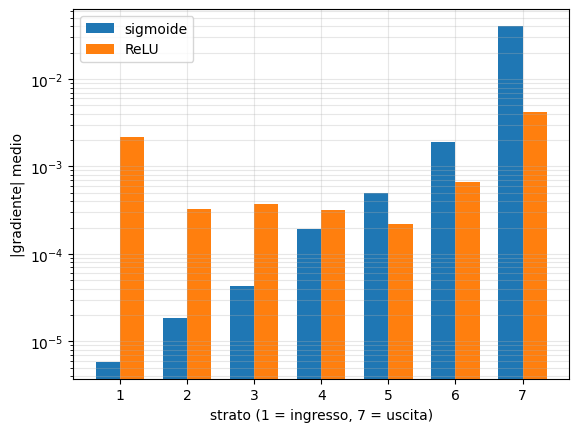

In [3]:
def gradiente_per_strato(attivazione, strati=6, larghezza=8, seme=42):
    np.random.seed(seme)
    Ws = [np.random.randn(2 if i == 0 else larghezza, larghezza) * 0.5 for i in range(strati)] + [np.random.randn(larghezza) * 0.5]
    bs = [np.zeros(larghezza) for _ in range(strati)] + [0.0]
    if attivazione == "sigmoide":
        f, df = sigmoide, (lambda h, z: h * (1 - h))
    else:
        f, df = (lambda z: np.maximum(0, z)), (lambda h, z: (z > 0) * 1.0)
    hs, zs = [X], []
    for W, b in zip(Ws[:-1], bs[:-1]):
        z = hs[-1] @ W + b; zs.append(z); hs.append(f(z))
    y_hat = sigmoide(hs[-1] @ Ws[-1] + bs[-1])
    delta = 2 * (y_hat - y_xor) / 4 * y_hat * (1 - y_hat)
    norme = [np.abs(hs[-1].T @ delta).mean()]
    dh = np.outer(delta, Ws[-1])
    for k in range(strati - 1, -1, -1):          # backpropagation strato per strato
        dz = dh * df(hs[k + 1], zs[k])
        norme.append(np.abs(hs[k].T @ dz).mean())
        dh = dz @ Ws[k].T
    return norme[::-1]                           # dal primo strato all'uscita

ns, nr = gradiente_per_strato("sigmoide"), gradiente_per_strato("relu")
for k, (a, b) in enumerate(zip(ns, nr)):
    print(f"strato {k+1}: sigmoide {a:.1e}   ReLU {b:.1e}")
x = np.arange(1, 8)
plt.bar(x - 0.18, ns, 0.36, label="sigmoide"); plt.bar(x + 0.18, nr, 0.36, label="ReLU")
plt.yscale("log"); plt.xlabel("strato (1 = ingresso, 7 = uscita)"); plt.ylabel("|gradiente| medio"); plt.legend(); plt.grid(alpha=0.3, which="both"); plt.show()

## 2.12 Approssimazione universale: una rete a un solo strato nascosto su sin(2x) + 0.3x

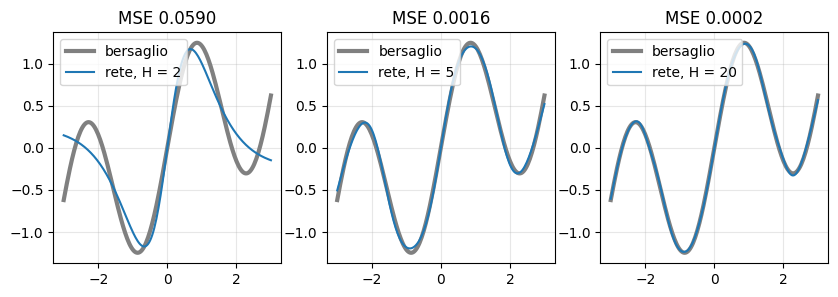

In [4]:
xs = np.linspace(-3, 3, 200)[:, None]
ys = np.sin(2 * xs[:, 0]) + 0.3 * xs[:, 0]

def approssima(H, epoche=20000, tasso=0.05, seme=42):
    np.random.seed(seme)
    W1 = np.random.randn(1, H) * 2; b1 = np.random.uniform(-3, 3, H) * np.abs(W1[0]); W2 = np.random.randn(H) * 0.5; b2 = 0.0
    for _ in range(epoche):
        h = np.tanh(xs @ W1 + b1); y_hat = h @ W2 + b2
        delta2 = 2 * (y_hat - ys) / len(ys)
        delta1 = np.outer(delta2, W2) * (1 - h ** 2)
        W1 -= tasso * (xs.T @ delta1); b1 -= tasso * delta1.sum(0); W2 -= tasso * (h.T @ delta2); b2 -= tasso * delta2.sum()
    return np.tanh(xs @ W1 + b1) @ W2 + b2

fig, ax = plt.subplots(1, 3, figsize=(10, 3))
for a, H in zip(ax, (2, 5, 20)):
    y_hat = approssima(H)
    a.plot(xs, ys, color="gray", lw=3, label="bersaglio"); a.plot(xs, y_hat, lw=1.5, label=f"rete, H = {H}")
    a.set_title(f"MSE {np.mean((y_hat - ys) ** 2):.4f}"); a.legend(); a.grid(alpha=0.3)
plt.show()